In [2]:
import requests
from urllib.parse import urljoin
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from bs4 import BeautifulSoup
import json
import pickle
import time
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from hazm import Normalizer, word_tokenize, stopwords_list, Stemmer
import pandas as pd

## 1. Data Collection

Crawling about 1000 Persian news articles from **Mehrnews** (https://www.mehrnews.com).  
The scraper visits paginated section pages to collect unique article URLs, then fetches each article to extract the title and body text.

In [2]:
import requests
import time
import random
import json
from urllib.parse import urljoin
from bs4 import BeautifulSoup
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/90.0.4430.93 Safari/537.36'
}

BASE_URL = "https://www.mehrnews.com"
START_URL = "https://www.mehrnews.com/archive?tp=5"

def get_session_with_retries():
    """Create a session with very high retry tolerance."""
    session = requests.Session()
    retry_strategy = Retry(
        total=20, 
        backoff_factor=5, # 5, 10, 20, 40, ... seconds between retries
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
        raise_on_status=False # don't raise on 503; we handle it ourselves
    )
    adapter = HTTPAdapter(max_retries=retry_strategy)
    session.mount("http://", adapter)
    session.mount("https://", adapter)
    return session

def fetch_page(url, session, max_manual_retries=5):
    """
    Fetch a page with:
      - Built‑in session retries (from above)
      - Additional manual retries with very long waits for 503
    """
    # Polite delay before every request
    time.sleep(random.uniform(3, 6))

    for attempt in range(max_manual_retries):
        try:
            response = session.get(url, headers=HEADERS, timeout=30)
            # If we get a 503, the session's retry may have already been exhausted,
            # but we catch it here and retry manually.
            if response.status_code == 503:
                wait = (2 ** (attempt + 4)) + random.uniform(0, 5)  # 16, 32, 64, 128, 256 sec
                print(f"  503 on {url}, waiting {wait:.1f}s before manual retry {attempt+1}/{max_manual_retries}...")
                time.sleep(wait)
                continue
            response.raise_for_status()
            return response
        except requests.exceptions.HTTPError as e:
            if response.status_code == 503 and attempt < max_manual_retries - 1:
                wait = (2 ** (attempt + 4)) + random.uniform(0, 5)
                print(f"  503 (HTTPError) on {url}, waiting {wait:.1f}s (retry {attempt+1}/{max_manual_retries})...")
                time.sleep(wait)
                continue
            print(f"HTTP error {response.status_code} on {url}: {e}")
            return None
        except (requests.exceptions.ConnectionError, requests.exceptions.Timeout) as e:
            if attempt < max_manual_retries - 1:
                wait = (2 ** attempt) * 10 + random.uniform(0, 5)
                print(f"  Connection/Timeout error on {url}, waiting {wait:.1f}s (retry {attempt+1}/{max_manual_retries})...")
                time.sleep(wait)
                continue
            print(f"Error fetching {url}: {e}")
            return None
        except Exception as e:
            print(f"Unexpected error fetching {url}: {e}")
            return None

    return None

def get_article_text(article_url, session):
    """Extract full text from an article page."""
    resp = fetch_page(article_url, session)
    if not resp:
        return ""
    try:
        soup = BeautifulSoup(resp.text, 'lxml')
        article_div = (soup.find('div', class_='item-text') or
                       soup.find('div', class_='news-body') or
                       soup.find('div', id='item-body') or
                       soup.find('div', itemprop='articleBody'))
        if article_div:
            return article_div.get_text(separator="\n", strip=True)
        body_div = soup.find('div', class_='item-body')
        if body_div:
            ps = body_div.find_all('p')
            return "\n".join(p.get_text(strip=True) for p in ps)
        return ""
    except Exception as e:
        print(f"Error parsing article {article_url}: {e}")
        return ""

def get_next_page_url(soup, current_url):
    """Extract the URL of the next page from pagination."""
    next_link = soup.find('a', rel='next')
    if next_link and next_link.get('href'):
        return urljoin(BASE_URL, next_link['href'])

    pagination = soup.find('ul', class_='pagination')
    if pagination:
        active_item = pagination.find('li', class_='active')
        if active_item:
            next_item = active_item.find_next_sibling('li')
            if next_item:
                link = next_item.find('a')
                if link and link.get('href'):
                    return urljoin(BASE_URL, link['href'])
    return None

def crawl_archive(max_articles=1100):
    session = get_session_with_retries()
    articles = []
    current_url = START_URL
    page_num = 1

    while len(articles) < max_articles and current_url:
        print(f"\nFetching page {page_num}: {current_url}")
        response = fetch_page(current_url, session)
        if not response:
            print("Failed to fetch page after all retries. Stopping.")
            break

        soup = BeautifulSoup(response.text, 'lxml')
        news_items = soup.select('li.news')
        if not news_items:
            print("No news items found on this page. Stopping pagination.")
            break

        print(f"Found {len(news_items)} articles on page {page_num}.")

        for item in news_items:
            if len(articles) >= max_articles:
                break

            a_tag = item.find('a', href=True)
            title_tag = item.find('h3') or item.find('h4')
            if not a_tag or not title_tag:
                continue

            title = title_tag.get_text(strip=True)
            link = urljoin(BASE_URL, a_tag['href'])
            print(f"  [{len(articles)+1}] {title[:50]}...")

            text = get_article_text(link, session)
            articles.append({
                "title": title,
                "link": link,
                "text": text
            })

            # Longer delay between articles to reduce load
            time.sleep(random.uniform(1, 3))

        # Find next page URL
        next_url = get_next_page_url(soup, current_url)
        if next_url and next_url != current_url:
            current_url = next_url
            page_num += 1
            # Extra long pause between pages
            time.sleep(random.uniform(5, 10))
        else:
            print("No next page found. Crawling finished.")
            break

    return articles


all_articles = crawl_archive(max_articles=1100)

documents = []
for idx, art in enumerate(all_articles, 1):
    documents.append({
        "doc_id": idx,
        "title": art["title"],
        "text": art["text"],
        "url": art["link"]
    })

output_file = "data.json"
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(documents, f, ensure_ascii=False, indent=2)

print(f"\nSaved {len(documents)} articles to {output_file}")


Fetching page 1: https://www.mehrnews.com/archive?tp=5
Found 29 articles on page 1.
  [1] حضور وزیر علوم در همایش بین‌المللی فناوری‌های نوین...
  [2] تراشه کمتر از یک نانومتر در جهان ساخته شد...
  [3] توسعه دیتا سنترهای هوش مصنوعی قیمت مک بوک وآی پد ر...
  [4] امروز آخرین فرصت ثبت نام در پذیرش کاردانی به کارشن...
  [5] فراخوان کسب دانش فنی ساخت یک قطعه مهم در صنایع حسا...
  [6] آیین‌نامه جامع مدیریت دانشگاه‌ها به شورای عالی انق...
  [7] حضور و سخنرانی وزیر علوم در زینبیه استانبول همزمان...
  [8] آنتروپیک شکاف در سیستم‌های دولت آمریکا را شناسایی ...
  [9] ابررایانه چینی از رقبای آمریکایی جلو زد...
  [10] حمایت مرکز همکاری‌های علمی وزارت علوم از ابتکارات ...
  [11] تغییر برنامه زمانی امتحانات دانشجویان دانشگاه صنعت...
  [12] ظرفیت ۶۸هزار نفری کاردانی به کارشناسی؛ کامپیوتر و ...
  [13] مراسم تودیع و معارفه رئیس دانشگاه هنر برگزار شد...
  [14] خوابگاه‌های علوم پزشکی تهران میزبان مهمانان مراسم ...
  [15] پاسخ رئیس بنیاد ملی نخبگان به ابهامات جذب نخبگان د...
  [16] راکت لب ۱۶ ساعته ماموریت 

## 2. Text Preprocessing

Using the **Hazm** library we:
- Normalize Unicode characters (`Normalizer`)
- Tokenize (`word_tokenize`)
- Remove stop words (Hazm’s default list)
- Stem each token (`Stemmer`)

The preprocessed text is stored as a list of stemmed tokens (`tokens` field).

In [3]:
# Load raw data
with open('data.json', 'r', encoding='utf-8') as f:
    raw_docs = json.load(f)

# Initialize Hazm tools
normalizer = Normalizer()
stop_words = set(stopwords_list())
stemmer = Stemmer()

# Preprocess each document's text
for doc in raw_docs:
    text = doc['text']
    # 1. Normalize
    normalized = normalizer.normalize(text)
    # 2. Tokenize
    tokens = word_tokenize(normalized)
    # 3. Remove stop words
    tokens = [tok for tok in tokens if tok not in stop_words]
    # 4. Stem
    stemmed_tokens = [stemmer.stem(tok) for tok in tokens]
    doc['tokens'] = stemmed_tokens

print(f"Preprocessed {len(raw_docs)} documents.")
with open('preprocessed_data.json', 'w', encoding='utf-8') as f:
    json.dump(raw_docs, f, ensure_ascii=False, indent=2)
print("preprocessed_data.json saved.")

Preprocessed 1100 documents.
preprocessed_data.json saved.


## 3. Inverted Index

Build an inverted index `{term: {doc_id: term_frequency}}` using the stemmed tokens.

In [4]:
inverted_index = defaultdict(dict)  # term -> {doc_id: tf}

for doc in raw_docs:
    doc_id = doc['doc_id']
    term_counts = Counter(doc['tokens'])
    for term, count in term_counts.items():
        inverted_index[term][doc_id] = count

print(f"Inverted index built with {len(inverted_index)} unique terms.")
with open('inverted_index.pkl', 'wb') as f:
    pickle.dump(dict(inverted_index), f)
print("inverted_index.pkl saved.")

Inverted index built with 16143 unique terms.
inverted_index.pkl saved.


## 4. TF‑IDF Vector Space Model

We use the formula:  
`weight(term, doc) = tf(term, doc) * log10(N / df(term))`  
where N = total number of documents, df(term) = document frequency.  
Query vector uses the same idf values and raw query term frequencies.  
Retrieval is based on cosine similarity.  

We precompute document norms and then evaluate queries efficiently via the inverted index.

In [5]:
# load inverted index
with open("./inverted_index.pkl", "rb") as index_file:
    inverted_index = pickle.load(index_file)

N = len(raw_docs)
doc_norms = {} # doc_id -> L2 norm
term_idf = {} # term -> log10(N/df)

# Compute df for each term
for term, postings in inverted_index.items():
    df = len(postings)
    idf = math.log10(N / df) if df > 0 else 0.0
    term_idf[term] = idf

# Compute doc norms using the TF‑IDF weights
for doc in raw_docs:
    doc_id = doc['doc_id']
    sum_sq = 0.0
    for term, tf in Counter(doc['tokens']).items():
        idf = term_idf.get(term, 0.0)
        weight = tf * idf
        sum_sq += weight ** 2
    doc_norms[doc_id] = math.sqrt(sum_sq) if sum_sq > 0 else 1e-10  # avoid zero division

print(f"Precomputed idf for {len(term_idf)} terms and norms for {len(doc_norms)} documents.")

Precomputed idf for 16143 terms and norms for 1100 documents.


In [6]:
def preprocess_query(query_text):
    """Apply the same preprocessing pipeline as document text: normalize, tokenize, remove stopwords, stem."""
    normalized = normalizer.normalize(query_text)
    tokens = word_tokenize(normalized)
    tokens = [tok for tok in tokens if tok not in stop_words]
    stemmed = [stemmer.stem(tok) for tok in tokens]
    return stemmed

def retrieve_tfidf(query_text, top_k=10):
    """Retrieve top k documents using TF‑IDF cosine similarity."""
    query_tokens = preprocess_query(query_text)
    if not query_tokens:
        return []
    query_tf = Counter(query_tokens)
    
    # Compute query vector and norm
    query_weights = {}
    q_norm_sq = 0.0
    for term, qtf in query_tf.items():
        idf = term_idf.get(term, 0.0)
        w = qtf * idf
        query_weights[term] = w
        q_norm_sq += w ** 2
    q_norm = math.sqrt(q_norm_sq) if q_norm_sq > 0 else 1e-10
    
    # Accumulate scores using inverted index
    scores = defaultdict(float)
    for term, qw in query_weights.items():
        if term not in inverted_index:
            continue
        idf = term_idf[term]
        for doc_id, tf in inverted_index[term].items():
            dw = tf * idf
            scores[doc_id] += qw * dw
    
    # Final cosine similarity
    results = []
    for doc_id, dot in scores.items():
        norm_d = doc_norms.get(doc_id, 1e-10)
        score = dot / (q_norm * norm_d)
        results.append((doc_id, score))
    
    results.sort(key=lambda x: x[1], reverse=True)
    return results[:top_k]

## 5. Language Model with Dirichlet Smoothing

Implementing the query‑likelihood model with Dirichlet smoothing (μ=1000)  
For document d:  
`P(w|d) = (tf(w,d) + μ * P(w|C)) / (|d| + μ)`  
`log P(q|d) = Σ_{w in q} log P(w|d)`  
Where `P(w|C)` = collection frequency of w / total number of stemmed tokens in the collection.  
Query terms that do not appear in the collection are skipped (they would yield zero probability).

In [7]:
# Collection statistics
total_tokens = sum(len(doc['tokens']) for doc in raw_docs)
collection_freq = {}  # term -> total count across all docs
for term, postings in inverted_index.items():
    collection_freq[term] = sum(postings.values())

# Doc lengths
doc_lengths = {doc['doc_id']: len(doc['tokens']) for doc in raw_docs}

print(f"Total tokens in collection: {total_tokens}")
print(f"Collection vocabulary size: {len(collection_freq)}")

Total tokens in collection: 337822
Collection vocabulary size: 16143


In [8]:
MU = 1000  # Dirichlet smoothing parameter

def retrieve_lm(query_text, top_k=10):
    """Retrieve top k documents using the language model with Dirichlet smoothing."""
    query_tokens = preprocess_query(query_text)
    if not query_tokens:
        return []
    
    # Filter tokens that exist in the collection (skip unseen terms)
    q_terms = [t for t in query_tokens if t in collection_freq]
    if not q_terms:
        return []
    
    # Precompute P(w|C) for query terms
    p_w_C = {t: collection_freq[t] / total_tokens for t in q_terms}
    
    # Score each document (brute-force over all docs; 1000 docs is fine)
    scores = {}
    for doc in raw_docs:
        doc_id = doc['doc_id']
        len_d = doc_lengths[doc_id]
        log_prob = 0.0
        # For efficiency, we can pre-store term counts per doc, but we use inverted_index lookups
        for t in q_terms:
            tf_d = inverted_index.get(t, {}).get(doc_id, 0)
            prob = (tf_d + MU * p_w_C[t]) / (len_d + MU)
            log_prob += math.log(prob)
        scores[doc_id] = log_prob
    
    results = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return results[:top_k]

## 6. Command‑Line Search Engine

A simple interactive interface that prompts for a Persian query, preprocesses it, and prints the top 10 results from both TF‑IDF and the Language Model. Type `exit` to quit.

In [9]:
def search_cli():
    """Interactive command‑line search."""
    print("\n=== Persian News Search Engine ===")
    print("Enter a Persian query or type 'exit' to quit.")
    while True:
        query = input("\nQuery: ").strip()
        if query.lower() == 'exit':
            print("Goodbye!")
            break
        if not query:
            continue
        
        # TF-IDF results
        print("\n--- TF‑IDF Top 10 ---")
        tfidf_res = retrieve_tfidf(query, top_k=10)
        for rank, (doc_id, score) in enumerate(tfidf_res, 1):
            print(f"{rank}. {doc_id} (score: {score:.6f})")
        if not tfidf_res:
            print("No results.")
        
        # Language Model results
        print("\n--- Language Model (Dirichlet μ=1000) Top 10 ---")
        lm_res = retrieve_lm(query, top_k=10)
        for rank, (doc_id, score) in enumerate(lm_res, 1):
            print(f"{rank}. {doc_id} (score: {score:.6f})")
        if not lm_res:
            print("No results.")

*(The following cell runs the CLI; uncomment to interact. To stop, type `exit`.)*

In [10]:
# search_cli()   # Uncomment to start the interactive search

## 7. Queries and Relevance Judgments

We define 10 Persian queries manually: 4 short (1 word), 3 medium (3 words), 3 long (5 words).  
For each query we automatically generate a relevance judgment file (`qrels.json`) by labelling as relevant any document that contains **all** stemmed query terms (after stop‑word removal).  

In [11]:
# 10 Persian queries
queries = {
    "q1": "متا",
    "q2": "دانشجو",
    "q3": "فناوری",
    "q4": "مهندسی",
    "q5": "شرکت دانش بنیان",
    "q6": "رشته مهندسی کامپیوتر",
    "q7": "پسا ساختار گرایی",
    "q8": "تهدید مشاغل توسط هوش مصنوعی",
    "q9": "ربات امدادگر در سوانح طبیعی",
    "q10": "هشدار جدید سازمان بهداشت جهانی"
}

print("Queries defined.")
for qid, qtext in queries.items():
    print(f"{qid}: {qtext}")

Queries defined.
q1: متا
q2: دانشجو
q3: فناوری
q4: مهندسی
q5: شرکت دانش بنیان
q6: رشته مهندسی کامپیوتر
q7: پسا ساختار گرایی
q8: تهدید مشاغل توسط هوش مصنوعی
q9: ربات امدادگر در سوانح طبیعی
q10: هشدار جدید سازمان بهداشت جهانی


In [12]:
# Generate qrels by checking containment of all stemmed query terms
qrels = {}  # query_id -> list of relevant doc_ids

for qid, qtext in queries.items():
    q_terms = set(preprocess_query(qtext))
    if not q_terms:
        qrels[qid] = []
        continue
    relevant_docs = []
    for doc in raw_docs:
        doc_terms = set(doc['tokens'])
        if q_terms.issubset(doc_terms):
            relevant_docs.append(doc['doc_id'])
    qrels[qid] = relevant_docs
    print(f"{qid}: {len(relevant_docs)} automatically relevant documents")

with open('qrels.json', 'w', encoding='utf-8') as f:
    json.dump(qrels, f, ensure_ascii=False, indent=2)
print("qrels.json saved.")

q1: 32 automatically relevant documents
q2: 114 automatically relevant documents
q3: 512 automatically relevant documents
q4: 108 automatically relevant documents
q5: 18 automatically relevant documents
q6: 11 automatically relevant documents
q7: 0 automatically relevant documents
q8: 0 automatically relevant documents
q9: 0 automatically relevant documents
q10: 1 automatically relevant documents
qrels.json saved.


## 8. Evaluation

For each of the 10 queries and both models, we compute:
- **P@5** (Precision at rank 5)
- **P@10** (Precision at rank 10)
- **NDCG@10** (Normalized Discounted Cumulative Gain, binary relevance)

NDCG formula:  
`DCG@10 = Σ_{i=1..10} rel_i / log2(i+1)`,  
`IDCG@10 = DCG of ideal ranking (all known relevant documents in top 10)`,  
`NDCG = DCG / IDCG` if IDCG > 0 else 0.

We present a comparison table and bar charts.

In [13]:
def compute_dcg(rel_list, k):
    """Compute DCG@k given binary relevance list (ordered)."""
    dcg = 0.0
    for i, rel in enumerate(rel_list[:k], start=1):
        if rel:
            dcg += 1.0 / math.log2(i+1)
    return dcg

def compute_idcg(num_rel_total, k):
    """IDCG@k for binary relevance: all relevant docs placed at top."""
    ideal_rels = [1] * min(num_rel_total, k)
    return compute_dcg(ideal_rels, k)

def evaluate_query(qid, qtext, model_retrieve_fn, top_k=10):
    """Return P@5, P@10, NDCG@10 for a given query and retrieval function."""
    results = model_retrieve_fn(qtext, top_k=top_k)
    retrieved_docs = [doc_id for doc_id, _ in results]
    relevant_set = set(qrels.get(qid, []))
    
    # Binary relevance for each rank
    rel_list = [1 if doc_id in relevant_set else 0 for doc_id in retrieved_docs]
    
    p5 = sum(rel_list[:5]) / 5.0 if len(rel_list) >= 5 else sum(rel_list)/max(1,len(rel_list))
    p10 = sum(rel_list[:10]) / 10.0 if len(rel_list) >= 10 else sum(rel_list)/max(1,len(rel_list))
    
    dcg = compute_dcg(rel_list, 10)
    idcg = compute_idcg(len(relevant_set), 10)
    ndcg = dcg / idcg if idcg > 0 else 0.0
    
    return p5, p10, ndcg


In [14]:
# Evaluate all queries for both models
tfidf_metrics = []
lm_metrics = []

for qid, qtext in queries.items():
    p5_tf, p10_tf, ndcg_tf = evaluate_query(qid, qtext, retrieve_tfidf)
    p5_lm, p10_lm, ndcg_lm = evaluate_query(qid, qtext, retrieve_lm)
    tfidf_metrics.append((qid, p5_tf, p10_tf, ndcg_tf))
    lm_metrics.append((qid, p5_lm, p10_lm, ndcg_lm))

print("Evaluation complete.")

Evaluation complete.


### Comparison Table

In [15]:
# Build DataFrame
columns = ['Query', 'Model', 'P@5', 'P@10', 'NDCG@10']
rows = []
for (qid, p5, p10, ndcg) in tfidf_metrics:
    rows.append([qid, 'TF-IDF', round(p5,4), round(p10,4), round(ndcg,4)])
for (qid, p5, p10, ndcg) in lm_metrics:
    rows.append([qid, 'LM (Dirichlet)', round(p5,4), round(p10,4), round(ndcg,4)])

df = pd.DataFrame(rows, columns=columns)
print("\nPer-query metrics:")
display(df)

# Compute averages
avg_tfidf = np.mean([[p5,p10,ndcg] for _,p5,p10,ndcg in tfidf_metrics], axis=0)
avg_lm = np.mean([[p5,p10,ndcg] for _,p5,p10,ndcg in lm_metrics], axis=0)
print("\nOverall Average:")
avg_df = pd.DataFrame([
    ['TF-IDF', round(avg_tfidf[0],4), round(avg_tfidf[1],4), round(avg_tfidf[2],4)],
    ['LM (Dirichlet)', round(avg_lm[0],4), round(avg_lm[1],4), round(avg_lm[2],4)]
], columns=['Model', 'Avg P@5', 'Avg P@10', 'Avg NDCG@10'])
display(avg_df)


Per-query metrics:


,Query,Model,P@5,P@10,NDCG@10
0,q1,TF-IDF,1.0,1.0,1.0000
1,q2,TF-IDF,1.0,1.0,1.0000
2,q3,TF-IDF,1.0,1.0,1.0000
3,q4,TF-IDF,1.0,1.0,1.0000
4,q5,TF-IDF,0.4,0.6,0.5056
5,q6,TF-IDF,1.0,0.7,0.8007
6,q7,TF-IDF,0.0,0.0,0.0000
7,q8,TF-IDF,0.0,0.0,0.0000
8,q9,TF-IDF,0.0,0.0,0.0000
9,q10,TF-IDF,0.0,0.0,0.0000



Overall Average:


,Model,Avg P@5,Avg P@10,Avg NDCG@10
0,TF-IDF,0.54,0.53,0.5306
1,LM (Dirichlet),0.56,0.56,0.6449


### Bar Charts

We plot per‑query and overall average comparisons.

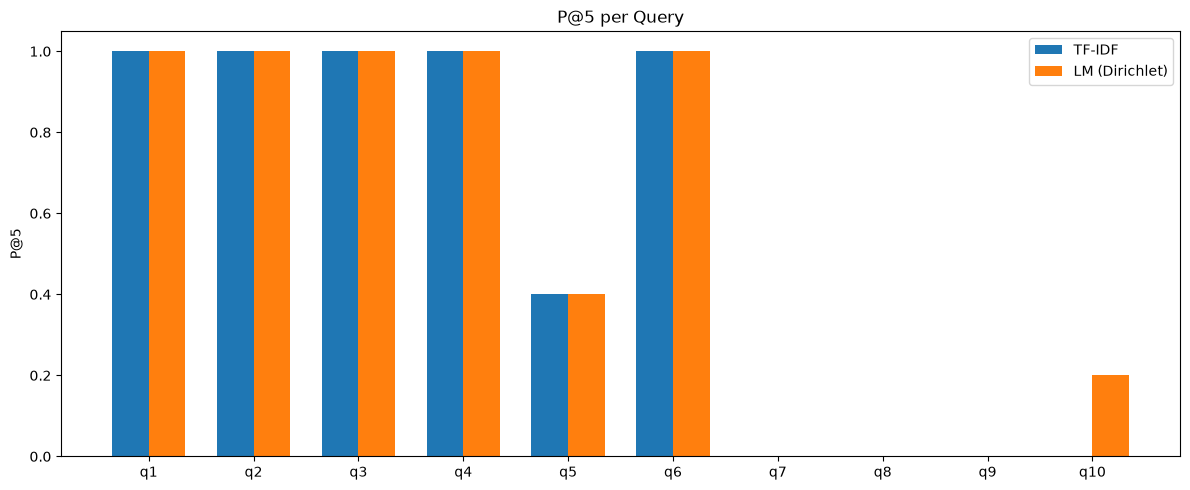

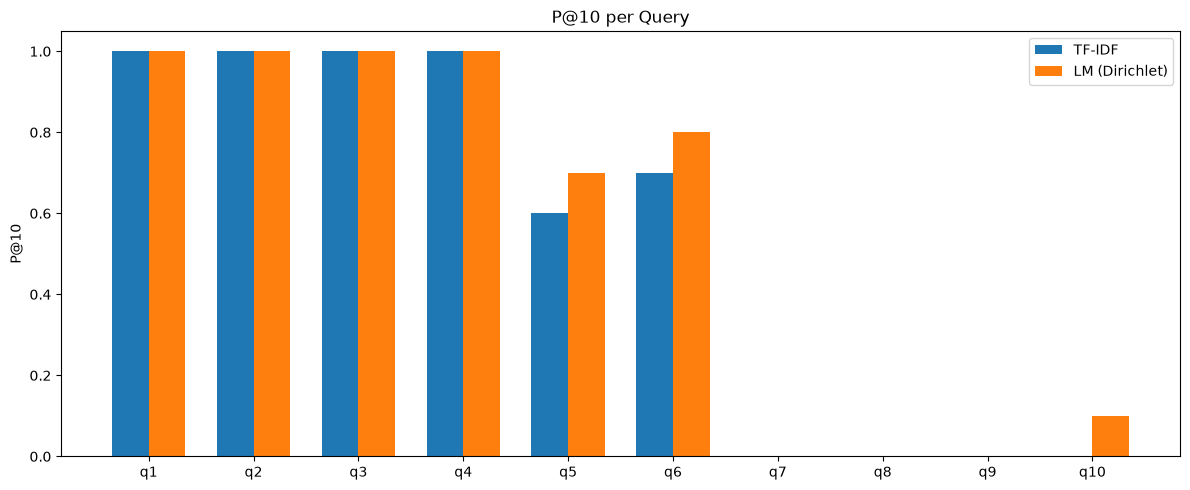

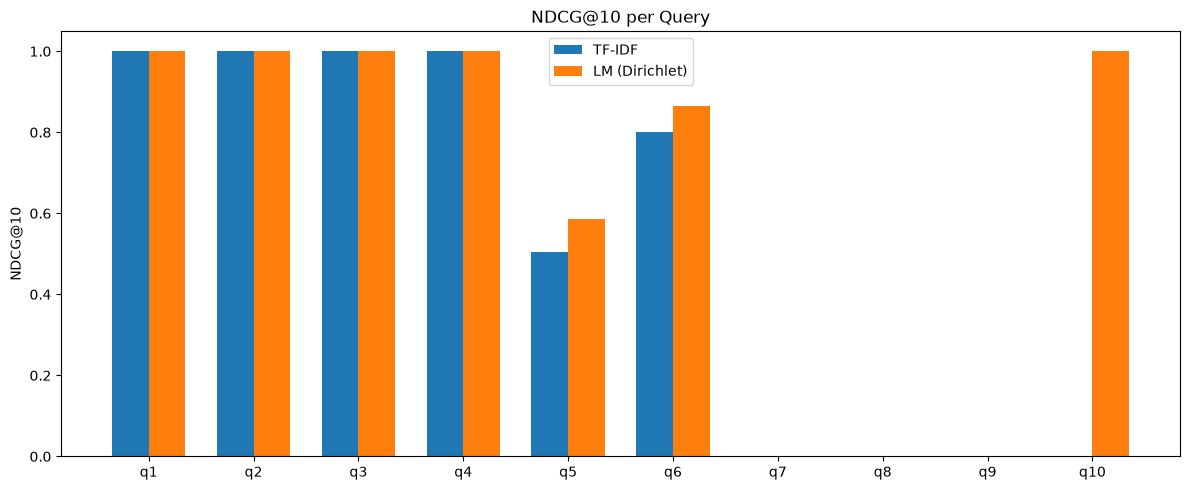

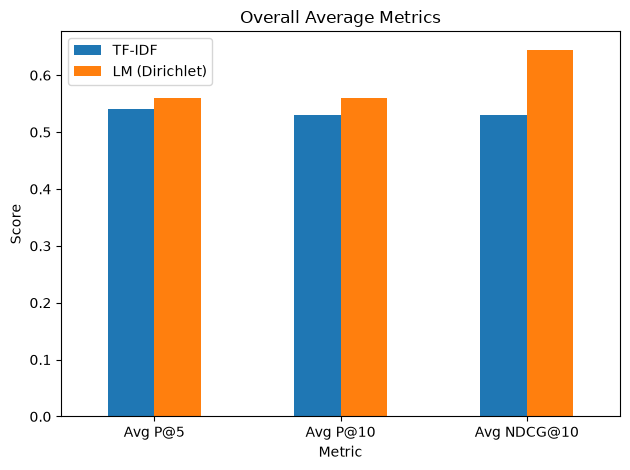

In [16]:
# Prepare data for bar charts
qids = [qid for qid,_,_,_ in tfidf_metrics]

def plot_metric(metric_name, metric_idx):
    tfidf_vals = [m[metric_idx] for m in tfidf_metrics]
    lm_vals = [m[metric_idx] for m in lm_metrics]
    x = np.arange(len(qids))
    width = 0.35
    fig, ax = plt.subplots(figsize=(12,5))
    bars1 = ax.bar(x - width/2, tfidf_vals, width, label='TF-IDF')
    bars2 = ax.bar(x + width/2, lm_vals, width, label='LM (Dirichlet)')
    ax.set_ylabel(metric_name)
    ax.set_title(f'{metric_name} per Query')
    ax.set_xticks(x)
    ax.set_xticklabels(qids)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_metric('P@5', 1)
plot_metric('P@10', 2)
plot_metric('NDCG@10', 3)

# Overall average bar chart
metrics_avg = pd.DataFrame({
    'Metric': ['Avg P@5', 'Avg P@10', 'Avg NDCG@10'],
    'TF-IDF': avg_tfidf,
    'LM (Dirichlet)': avg_lm
}).set_index('Metric')

fig, ax = plt.subplots()
metrics_avg.plot(kind='bar', ax=ax, rot=0)
ax.set_title('Overall Average Metrics')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()